<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Hito3_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hector Jimenez**

En esta tarea van a crear una red neuronal que clasifique mensajes como spam o no spam. Lo primero es descargar la data:

In [ ]:
!wget https://www.ivan-sipiran.com/downloads/spam.csv

--2023-11-19 16:36:38--  https://www.ivan-sipiran.com/downloads/spam.csv
Resolving www.ivan-sipiran.com (www.ivan-sipiran.com)... 66.96.149.31
Connecting to www.ivan-sipiran.com (www.ivan-sipiran.com)|66.96.149.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 471781 (461K)
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 460.72K  --.-KB/s    in 0.1s    

2023-11-19 16:36:38 (3.32 MB/s) - ‘spam.csv’ saved [471781/471781]



Los datos vienen en un archivo CSV que contiene dos columnas "text" y "label". La columna "text" contiene el texto del mensaje y la columna "label" contiene las etiquetas "ham" y "spam". Un mensaje "ham" es un mensaje que no se considera spam.

# Tarea
El objetivo de la tarea es crear una red neuronal que clasifique los datos entregados. Para lograr esto debes:



*   Implementar el pre-procesamiento de los datos que creas necesario.
*   Particionar los datos en 70% entrenamiento, 10% validación y 20% test.
*   Usa los datos de entrenamiento y valiadación para tus experimentos y sólo usa el conjunto de test para reportar el resultado final.

Para el diseño de la red neuronal puedes usar una red neuronal recurrente o una red basada en transformers. El objetivo de la tarea no es obtener el performance ultra máximo, sino entender qué decisiones de diseño afectan la solución de un problema como este. Lo que si es necesario (como siempre) es que discutas los resultados y decisiones realizadas.



In [ ]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


In [ ]:
data = pd.read_csv('spam.csv')
data

,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,spam
5568,Will Ì_ b going to esplanade fr home?,ham
5569,"Pity, * was in mood for that. So...any other s...",ham
5570,The guy did some bitching but I acted like i'd...,ham


In [ ]:
l = []
for i,j in enumerate(data.iloc[:,-1]):
  try:
    if j not in  ['ham','spam']:
      l.append(i)
  except:
    pass

0.8608987506992355

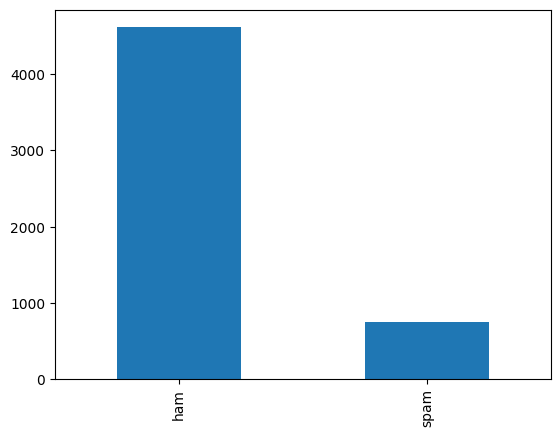

In [ ]:
data = data.drop(labels = l, axis = 0).reset_index(drop=True)
uniquevalues = np.unique(data.iloc[:,-1], return_counts=True)
data['label'].value_counts().plot( kind = 'bar' )

uniquevalues[1][0]/(np.sum(uniquevalues[1]))

# 1. Preprocesamiento de los datos

- Embeddings de variable objetivo

Este paso permite convertir las etiquetas de los mails a valores numericos.

In [ ]:
data['label_num'] = [1 if i == 'spam' else 0 for i in data['label']]

- Eliminacion de puntuaciones en strings

In [ ]:
from string import punctuation
def delete_puntuation(string):
  string = string.lower()
  string = ''.join([ i for i in string if i not in punctuation ])
  return string

data['text_clean'] = data['text'].apply(func = delete_puntuation)

- Hacer conteo de palabras

In [ ]:
from collections import Counter

all_strings = ' '.join(list(data['text_clean']))

print(all_strings[0:200])
print(data['text_clean'][0:2])

go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat ok lar joking wif u oni free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text f
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
Name: text_clean, dtype: object


In [ ]:
freq_words = Counter(all_strings.split()) #cerca de 9000 palabras unicas
sort_word = sorted(freq_words,key=freq_words.get, reverse = True )
word_index = { word:index for index,word in enumerate(sort_word,1) }

#convertir a vector numerico cada mensaje
num_mail = []
for i in data['text_clean']:
  num_mail.append([ word_index[k] for k in i.split() ])

In [ ]:
print(list(word_index.items())[0:10])
print(num_mail[100])
print(data['text_clean'][100])

[('to', 1), ('i', 2), ('you', 3), ('a', 4), ('the', 5), ('u', 6), ('and', 7), ('in', 8), ('is', 9), ('me', 10)]
[830, 233, 144, 2, 166, 554, 1, 29, 19, 2, 314, 357, 2, 939, 41, 18, 1558, 1019, 7, 1223, 11, 633, 2871, 1, 1808, 191, 1223, 1224, 18, 11, 4300, 1225, 14, 83, 476, 1558]
wow youre right i didnt mean to do that i guess once i gave up on boston men and changed my search location to nyc something changed cuz on my signin page it still says boston


- Padding de los vectores.

La Figura permite analizar las longitudes de cada reseña.

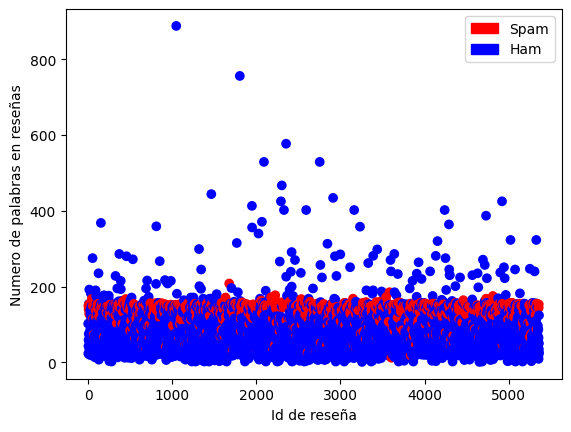

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

legend_elements = [#Line2D([0], [0], marker='o', color='w', label='Scatter',markerfacecolor='g', markersize=15),
                   Patch(facecolor='red', edgecolor='red', label='Spam'),
                   Patch(facecolor='blue', edgecolor='blue', label='Ham')]

colord = {'ham':'blue','spam':'red'}
plt.scatter(x = data.index ,y = [len(i) for i in data['text_clean']], c = data['label'].map(colord))
plt.ylabel('Numero de palabras en reseñas')
plt.xlabel('Id de reseña')
plt.legend(handles = legend_elements)

Las longitudes estan en un rango aproximado entre 1 y 800, siendo 200 un una cota superior que permite contener a la mayor cantidad de mails. Esto lleva a seleccionar 200 como el largo maximo de un mail. De esta manera, los vectores numericos de los mails que tengan una longitud menor a 200 seran rellenados con 0 al inicio del vector de tal manera de obtener una longitud 200. En cambio, los vectores numericos de longitud mayor a 200 seran cortados en la posicion 200.

In [ ]:
#eliminacion de datos con 0 palabras
idx_nonzero_len = [ idx for idx,mail in enumerate(num_mail) if len(mail) > 0 ]
X_num_mail = [num_mail[i] for i in idx_nonzero_len]
Y_num_label = [data['label_num'][i] for i in idx_nonzero_len]

In [ ]:
#funcion para hacer padding en los datos
def pad_features(words_embedding, seq_length):
  features = np.zeros((len(words_embedding), seq_length), dtype=int)
  for i, row in enumerate(words_embedding):
    features[i, -len(row):] = np.array(row)[:seq_length] # -len(row): from -len(row) to postion 200. the rest is zero
  return features

In [ ]:
max_lenght = 200
features = pad_features(words_embedding = X_num_mail, seq_length = max_lenght)

- Particion de datos en train val y test de manera estratificada

In [ ]:
#unique_y = np.unique(Y_num_label)
#id_train, id_val, id_test = [],[],[]

#for i, label in enumerate(unique_y):
#  id_data =  [k for k in range(len(Y_num_label)) if Y_num_label[k] == label ] #list(range(features.shape[0]))
#  random.shuffle(id_data)
#  id_train += id_data[0:int(len(id_data)*0.7)]
#  id_val   += id_data[int(len(id_data)*0.7):int(len(id_data)*0.8)]
#  id_test  += id_data[int(len(id_data)*0.8):int(len(id_data)+1)]

#X_train, X_val, X_test = features[id_train ,:],features[id_val ,:],features[id_test ,:]
#Y_train, Y_val, Y_test = np.array(Y_num_label)[id_train],np.array(Y_num_label)[id_val],np.array(Y_num_label)[id_test]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(features, np.array(Y_num_label), test_size=0.2,stratify= Y_num_label , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/80, stratify= Y_train, random_state=seed)

- Datasets y dataloaders

In [ ]:


# crear Tensor datasets
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
valid_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test))
# dataloaders
batch_size = 50

train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size, drop_last=True)

In [ ]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()

if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [ ]:
def accuracy(y_pred,y_real):
  running_corrects = torch.sum(torch.Tensor(y_pred) == torch.Tensor(y_real))
  return float(running_corrects/len(y_pred))

accuracy([1,2,3,7,8],[1,2,5,7,8])

0.800000011920929

# 1 Resolucion del problema

- RED NEURONAL

In [ ]:
import torch.nn as nn

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):

        super(SentimentRNN, self).__init__()

        self.output_size = output_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim

        # Capas embedding y LSTM
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                            dropout=drop_prob, batch_first=True)

        # dropout
        self.dropout = nn.Dropout(drop_prob)

        # Capa lineal y sigmoide
        self.fc = nn.Linear(hidden_dim, output_size)
        self.sig = nn.Sigmoid()

    def forward(self, x, hidden):

        embeds = self.embedding(x)
        lstm_out, hidden = self.lstm(embeds, hidden)

        #Tomamos solo el último valor de salida del LSTM
        lstm_out = lstm_out[:,-1,:]

        # dropout y fully-connected
        out = self.dropout(lstm_out)
        out = self.fc(out)

        # sigmoide
        sig_out = self.sig(out)

        # retornar sigmoide y último estado oculto
        return sig_out, hidden


    def init_hidden(self, batch_size):
        # Crea dos nuevos tensores con tamaño n_layers x batch_size x hidden_dim,
        # inicializados a cero, para estado oculto y memoria de LSTM
        weight = next(self.parameters()).data

        if(train_on_gpu):
          hidden = (weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().cuda(),
                   weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().cuda())
        else:
          hidden = (weight.new(self.n_layers, batch_size, self.hidden_dim).zero_(),
                   weight.new(self.n_layers, batch_size, self.hidden_dim).zero_())

        return hidden

In [ ]:
# Instanciamos la red
vocab_size = len(word_index) + 1 # +1 for zero padding + our word tokens
output_size = 1
embedding_dim = 400
hidden_dim = 256
n_layers = 2
net = SentimentRNN(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)
print(net)

SentimentRNN(
  (embedding): Embedding(9197, 400)
  (lstm): LSTM(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)


In [ ]:
# loss and optimization functions
lr=0.001
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

In [ ]:
# training params
epochs = 10
counter = 0
print_every = 100
clip=5 # gradient clipping

# Enviar red al GPU
if(train_on_gpu):
    net.cuda()

net.train()
# Bucle de entrenamiento
for e in range(epochs):
    # Inicializar estado oculto
    h = net.init_hidden(batch_size) # deberia tener dim (nlayers, batch size , hidden dim)

    # Bucle para batchs
    for inputs, labels in train_loader: #input deberia tener dim (batch size x len seq)
        counter += 1

        if(train_on_gpu):
            inputs, labels = inputs.cuda(), labels.cuda()

        # Crear nuevas variables para estados ocultos, sino se haría
        # backprop para todos los pasos del bucle
        h = tuple([each.data for each in h])

        net.zero_grad()

        # Hacer pasada forward
        output, h = net(inputs, h)

        # Calcular loss y hacer backprop
        loss = criterion(output.squeeze(), labels.float())
        loss.backward()
        # gradient clipping
        nn.utils.clip_grad_norm_(net.parameters(), clip)
        optimizer.step()

        # Mensajes
        if counter % print_every == 0:
            # Validation loss
            val_h = net.init_hidden(batch_size)
            val_losses = []
            net.eval()
            y_pred, y_real = [], []

            for inputs, labels in valid_loader:

                val_h = tuple([each.data for each in val_h])

                if(train_on_gpu):
                    inputs, labels = inputs.cuda(), labels.cuda()

                output, val_h = net(inputs, val_h)
                val_loss = criterion(output.squeeze(), labels.float())
                val_losses.append(val_loss.item())

                y_pred +=  (output > 0.5 ).squeeze().float().tolist()
                y_real +=  labels.float().tolist()

            acc_val = accuracy(y_pred,y_real)
            net.train()
            print("Época: {}/{}...".format(e+1, epochs),
                  "Paso: {}...".format(counter),
                  "Loss: {:.6f}...".format(loss.item()),
                  "Val Loss: {:.6f}".format(np.mean(val_losses)),
                  "Accuracy Val: {:.6f}".format(acc_val) )

Época: 2/10... Paso: 100... Loss: 0.009965... Val Loss: 0.094084 Accuracy Val: 0.968000
Época: 3/10... Paso: 200... Loss: 0.008279... Val Loss: 0.077834 Accuracy Val: 0.968000
Época: 4/10... Paso: 300... Loss: 0.005791... Val Loss: 0.084473 Accuracy Val: 0.978000
Época: 6/10... Paso: 400... Loss: 0.000256... Val Loss: 0.108983 Accuracy Val: 0.976000
Época: 7/10... Paso: 500... Loss: 0.000139... Val Loss: 0.140115 Accuracy Val: 0.972000
Época: 8/10... Paso: 600... Loss: 0.000169... Val Loss: 0.178305 Accuracy Val: 0.968000
Época: 10/10... Paso: 700... Loss: 0.000026... Val Loss: 0.177664 Accuracy Val: 0.970000


Evaluacion en test

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

net.eval()
y_pred, y_real = [], []
for inputs, labels in test_loader:
  val_h = tuple([each.data for each in val_h])
  if(train_on_gpu):
    inputs, labels = inputs.cuda(), labels.cuda()
    output, val_h = net(inputs, val_h)

  y_pred +=  (output > 0.5 ).squeeze().float().tolist()
  y_real +=  labels.float().tolist()

acc_test = accuracy(y_pred,y_real)
print(acc_test)
confusion_matrix(y_real, y_pred)
classification_report(y_real,y_pred,output_dict=True)


0.9752380847930908


{'0.0': {'precision': 0.9761904761904762,
  'recall': 0.9955849889624724,
  'f1-score': 0.9857923497267759,
  'support': 906},
 '1.0': {'precision': 0.9682539682539683,
  'recall': 0.8472222222222222,
  'f1-score': 0.9037037037037037,
  'support': 144},
 'accuracy': 0.9752380952380952,
 'macro avg': {'precision': 0.9722222222222222,
  'recall': 0.9214036055923474,
  'f1-score': 0.9447480267152397,
  'support': 1050},
 'weighted avg': {'precision': 0.9751020408163266,
  'recall': 0.9752380952380952,
  'f1-score': 0.9745344782721831,
  'support': 1050}}

**Analisis de resultados:**
En esta tarea se evalua el rendimiento y capacidad del modelo con el dataset de test. La evaluacion se lleva a cabo considerando promedios de metricas **NO** ponderados según cantidad de datos por clase. Las metricas analizadas son precision, recall y f1-score. El modelo obtiene un rendimiento alto debido a que tiene metricas promedio de 0.97, 0.92 y 0.94 en precision, recall y f1-score, respectivamente. El modelo obtiene metricas superiores a 0.97 para la clase '0' (correo ham), mientras que valores superiores a 0.84 para la clase '1'(spam). Es decir, el modelo no esta predicciendo correctamente la clase spam debido a falsos negativos (recall). Esto ocurre cuando el modelo predice que un correo es 'ham' cuando en realidad es 'spam'. Este problema se puede deber a multiples condiciones:

- Los datos estan desbalanceados, ya que hay una cantidad mucho mayor de correos tipo 'ham' que 'spam'. Esto puede afectar el proceso de entrenamiento, ya que la red intentará minimizar los errores de todos los datos, dando lugar a correcciones mas significativas para la clase mayoritaria (ham). Por lo tanto, la red se centrará más en reducir los errores los errores de prediccion de correos tipo 'ham', ya que estos tendrán un impacto más notable en las metricas de rendimiento.




# 2 Experimento de oversampling con LSTM

Una posible solucion al problema de desbalance es utilizar tecnicas de oversampling. Esta tecnica consiste en seleccionar aleatoriamente datos de la **clase minoritaria en el conjunto de datos de entrenamiento** hasta igualar el numero de datos de todas las clases presenten en el dataset de entrenamiento. A modo de experimentacion se decide probar esta tecnica con el objetivo de evaluar si la red neuronal mejora su rendimiento sobre la clase 'spam'.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(features, np.array(Y_num_label), test_size=0.2,stratify= Y_num_label , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/80, stratify= Y_train, random_state=seed)

In [ ]:
Y_train = pd.DataFrame(Y_train)
counts = np.unique(Y_train, return_counts = True)
id_oversampling = random.choices( list(Y_train[Y_train[0].isin([1])].index) ,k = max(counts[1]) - min(counts[1]) )
Y_train = list(Y_train[0]) + [1]*(max(counts[1]) - min(counts[1]))
X_train = np.concatenate( (X_train, X_train[ id_oversampling ,:]), axis = 0)

- Datasets y dataloaders

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
# crear Tensor datasets
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(np.array(Y_train)))
valid_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test))
# dataloaders
batch_size = 50
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size, drop_last=True)

In [ ]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [ ]:
net = SentimentRNN(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)
print(net)
# loss and optimization functions
lr=0.001
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

SentimentRNN(
  (embedding): Embedding(9197, 400)
  (lstm): LSTM(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)


In [ ]:
# training params
epochs = 10
counter = 0
print_every = 100
clip=5 # gradient clipping
# Enviar red al GPU
if(train_on_gpu):
    net.cuda()
net.train()
# Bucle de entrenamiento
for e in range(epochs):
    # Inicializar estado oculto
    h = net.init_hidden(batch_size) # deberia tener dim (nlayers, batch size , hidden dim)
    # Bucle para batchs
    for inputs, labels in train_loader: #input deberia tener dim (batch size x len seq)
        counter += 1
        if(train_on_gpu):
            inputs, labels = inputs.cuda(), labels.cuda()
        # Crear nuevas variables para estados ocultos, sino se haría
        # backprop para todos los pasos del bucle
        h = tuple([each.data for each in h])
        net.zero_grad()
        # Hacer pasada forward
        output, h = net(inputs, h)
        # Calcular loss y hacer backprop
        loss = criterion(output.squeeze(), labels.float())
        loss.backward()
        # gradient clipping
        nn.utils.clip_grad_norm_(net.parameters(), clip)
        optimizer.step()
        # Mensajes
        if counter % print_every == 0:
            # Validation loss
            val_h = net.init_hidden(batch_size)
            val_losses = []
            net.eval()
            y_pred, y_real = [], []
            for inputs, labels in valid_loader:
                val_h = tuple([each.data for each in val_h])
                if(train_on_gpu):
                    inputs, labels = inputs.cuda(), labels.cuda()
                output, val_h = net(inputs, val_h)
                val_loss = criterion(output.squeeze(), labels.float())
                val_losses.append(val_loss.item())
                y_pred +=  (output > 0.5 ).squeeze().float().tolist()
                y_real +=  labels.float().tolist()
            acc_val = accuracy(y_pred,y_real)
            net.train()
            print("Época: {}/{}...".format(e+1, epochs),
                  "Paso: {}...".format(counter),
                  "Loss: {:.6f}...".format(loss.item()),
                  "Val Loss: {:.6f}".format(np.mean(val_losses)),
                  "Accuracy Val: {:.6f}".format(acc_val) )

Época: 1/10... Paso: 100... Loss: 0.037129... Val Loss: 0.105219 Accuracy Val: 0.966000
Época: 2/10... Paso: 200... Loss: 0.004452... Val Loss: 0.092739 Accuracy Val: 0.972000
Época: 3/10... Paso: 300... Loss: 0.000241... Val Loss: 0.115940 Accuracy Val: 0.978000
Época: 4/10... Paso: 400... Loss: 0.000089... Val Loss: 0.117580 Accuracy Val: 0.980000
Época: 4/10... Paso: 500... Loss: 0.000079... Val Loss: 0.144948 Accuracy Val: 0.978000
Época: 5/10... Paso: 600... Loss: 0.000062... Val Loss: 0.134084 Accuracy Val: 0.980000
Época: 6/10... Paso: 700... Loss: 0.000023... Val Loss: 0.140447 Accuracy Val: 0.980000
Época: 7/10... Paso: 800... Loss: 0.000017... Val Loss: 0.159808 Accuracy Val: 0.978000
Época: 7/10... Paso: 900... Loss: 0.000016... Val Loss: 0.142716 Accuracy Val: 0.980000
Época: 8/10... Paso: 1000... Loss: 0.000016... Val Loss: 0.167794 Accuracy Val: 0.978000
Época: 9/10... Paso: 1100... Loss: 0.000010... Val Loss: 0.163672 Accuracy Val: 0.978000
Época: 10/10... Paso: 1200... 

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
net.eval()
y_pred, y_real = [], []
for inputs, labels in test_loader:
  val_h = tuple([each.data for each in val_h])
  if(train_on_gpu):
    inputs, labels = inputs.cuda(), labels.cuda()
    output, val_h = net(inputs, val_h)
  y_pred +=  (output > 0.5 ).squeeze().float().tolist()
  y_real +=  labels.float().tolist()
acc_test = accuracy(y_pred,y_real)
print(acc_test)
confusion_matrix(y_real, y_pred)
classification_report(y_real,y_pred,output_dict=True)

0.9809523820877075


{'0.0': {'precision': 0.9825708061002179,
  'recall': 0.9955849889624724,
  'f1-score': 0.9890350877192983,
  'support': 906},
 '1.0': {'precision': 0.9696969696969697,
  'recall': 0.8888888888888888,
  'f1-score': 0.927536231884058,
  'support': 144},
 'accuracy': 0.9809523809523809,
 'macro avg': {'precision': 0.9761338878985938,
  'recall': 0.9422369389256806,
  'f1-score': 0.9582856598016781,
  'support': 1050},
 'weighted avg': {'precision': 0.9808052513934867,
  'recall': 0.9809523809523809,
  'f1-score': 0.9806009589190368,
  'support': 1050}}

La tecnica de oversampling permite mejorar levemente el rendimiento de la red neuronal recurrente sin incurrir en overfitting. El modelo con oversampling obtiene valores promedio sin ponderación de 0.98, 0.94 y 0.96 para las metricas precision, recall y f1-score, respectivamente. Es decir, mejora en 0.2 en la metrica recall con respecto al modelo entrenado sin oversampling. Esta mejora se da sobre la prediccion de la clase 'spam'. Por lo tanto, la tecnica oversampling puede ser adecuada si se quiere reducir los errores de prediccion sobre la clase minoritaria de un problema de clasificación.

# Conclusiones:

- La red neuronal recurrente LSTM genera predicciones de manera acertada para la clasificacion de tipos de correos ham vs spam. Todos los modelos entrenados obtienen valores promedios superiores a 0.92 en precision, recall y f1-score. Este tipo de modelos funciona correctamente sobre trabajos asociados a palabras debido a que considera las relaciones entre palabras y permite identificar la estructura de correos de tipo spam en base al contexto extraido de las palabras.

- La red neuronal recurrente LSTM es un modelo de aprendizaje profundo que extrae las caracteristicas de los datos utilizando embeddings. Esta tecnica funciona de manera acertada debido a que se tiene un dataset con un gran numero de datos. Esto permite a la red entrenarse de manera de obtener una caracterizacion de las palabras para este problema en especifico.